# MINERIA DE DATOS (020-81) / Trabajo Primer Corte

**Integrantes del grupo:**
1. Julian David Cabrera Barragan
2. Nelson David Posso Suarez
3. Edward Julian Garcia Gaitan
4. Juan David Cordoba Aguirre

Importación de libreríás:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5)

Carga y vista inicial de datos:

In [2]:
df = pd.read_csv("Cancer_Data.csv")

print("Filas, columnas:", df.shape)
display(df.head())
display(df.info())

Filas, columnas: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

None

### 1. Comprensión del problema

- **¿Qué problema están resolviendo?**  
Se busca analizar las características clínicas medidas en tumores mamarios para diferenciar entre diagnósticos **benignos (B)** y **malignos (M)**, identificando patrones que permitan apoyar una clasificación temprana y confiable.

- **¿Qué decisión se podría tomar con estos datos?**  
Con este análisis se pueden priorizar casos con alta probabilidad de malignidad para evaluación clínica más rápida, definir umbrales de riesgo y apoyar decisiones de tamizaje o seguimiento. Ademas de la posibilidad de usar estos datos para entrenamiento y predicción de cancer para definir si el cancer es benigno o maligno, lo cual podra ayudar a medicos en la toma de descisiones.

- **¿Quién usaría este análisis?**  
Principalmente personal médico (oncología, radiología, medicina general), equipos de apoyo diagnóstico, investigadores biomédicos y gestores hospitalarios que necesiten criterios cuantitativos para priorización.

- **¿Por qué es importante?**  
Porque la detección oportuna del cáncer de mama impacta directamente en pronóstico, tratamiento y supervivencia. Un buen análisis reduce retrasos diagnósticos y mejora la asignación de recursos clínicos.

---

#### **PREGUNTAS GUÍA:**

- **¿El problema es descriptivo, predictivo o explicativo?**  
Es principalmente **predictivo** (clasificar B/M), con componente **descriptivo** en la etapa EDA para entender el comportamiento de las variables.

- **¿Qué variable sería la más importante a analizar?**  
La variable central es **`diagnosis`**, porque es la variable objetivo (resultado clínico). A partir de ella se evalúa qué variables de entrada (por ejemplo `concave points_worst`, `perimeter_worst`, `radius_worst`) tienen mayor poder para distinguir malignidad.

- **¿Qué riesgo hay si se interpreta mal este problema?**  
El mayor riesgo es clínico donde se generen decisiones erradas. En particular, un **falso negativo** (clasificar Maligno como Benigno) puede retrasar tratamiento. También hay riesgo de sobrediagnóstico y uso ineficiente de recursos con demasiados falsos positivos.

### 2. Comprensión de los datos

**Fuente del dataset (Kaggle):**  
https://www.kaggle.com/datasets/erdemtaha/cancer-data

**Descripción del dataset**  
El conjunto de datos contiene mediciones morfológicas de núcleos celulares obtenidas a partir de imágenes digitalizadas de masas mamarias (biopsia por aspiración con aguja fina). El objetivo clínico es diferenciar entre tumores **benignos (B)** y **malignos (M)**.

**Variables:**

1. **id**: Identificador único del caso/paciente.
2. **diagnosis**: Diagnóstico (B = Benigno, M = Maligno).
3. **radius_mean**: Promedio del radio (distancia media del centro al perímetro).
4. **texture_mean**: Promedio de la textura (desviación estándar de los valores de gris).
5. **perimeter_mean**: Promedio del perímetro.
6. **area_mean**: Promedio del área.
7. **smoothness_mean**: Promedio de suavidad (variación local de la longitud del radio).
8. **compactness_mean**: Promedio de compacidad, calculada como (perímetro^2 / área) - 1.0.
9. **concavity_mean**: Promedio de concavidad (severidad de porciones cóncavas del contorno).
10. **concave points_mean**: Promedio del número de puntos cóncavos del contorno.
11. **symmetry_mean**: Promedio de simetría.
12. **fractal_dimension_mean**: Promedio de dimensión fractal (aprox. "coastline" - 1).
13. **radius_se**: Error estándar del radio.
14. **texture_se**: Error estándar de la textura.
15. **perimeter_se**: Error estándar del perímetro.
16. **area_se**: Error estándar del área.
17. **smoothness_se**: Error estándar de la suavidad.
18. **compactness_se**: Error estándar de la compacidad.
19. **concavity_se**: Error estándar de la concavidad.
20. **concave points_se**: Error estándar de los puntos cóncavos.
21. **symmetry_se**: Error estándar de la simetría.
22. **fractal_dimension_se**: Error estándar de la dimensión fractal.
23. **radius_worst**: Valor peor/máximo del radio.
24. **texture_worst**: Valor peor/máximo de la textura.
25. **perimeter_worst**: Valor peor/máximo del perímetro.
26. **area_worst**: Valor peor/máximo del área.
27. **smoothness_worst**: Valor peor/máximo de la suavidad.
28. **compactness_worst**: Valor peor/máximo de la compacidad.
29. **concavity_worst**: Valor peor/máximo de la concavidad.
30. **concave points_worst**: Valor peor/máximo de los puntos cóncavos.
31. **symmetry_worst**: Valor peor/máximo de la simetría.
32. **fractal_dimension_worst**: Valor peor/máximo de la dimensión fractal.

**Tipos de variables**

- **Variables categóricas**: 1
    diagnosis (tipo objeto/texto)

- **Variables numéricas**: 31
    id (entero)
    30 variables continuas de características morfológicas (float)

- **Valores faltantes:**
    Se detectó que el dataset contiene una columna sin nombre y totalmente vacía la cual es la última columna:

In [3]:
# Deteccion de valores faltantes en el dataset

# 1) Cantidad de faltantes por columna
faltantes_por_columna = df.isna().sum().sort_values(ascending=False)
print("Faltantes por columna:")
display(faltantes_por_columna)

# 2) Total de faltantes en todo el dataset
total_faltantes = int(df.isna().sum().sum())
print(f"\nTotal de valores faltantes en el dataset: {total_faltantes}")

# 3) Porcentaje de faltantes por columna
porcentaje_faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
print("\nPorcentaje de faltantes por columna (%):")
display(porcentaje_faltantes)


Faltantes por columna:


Unnamed: 32                569
id                           0
diagnosis                    0
texture_mean                 0
radius_mean                  0
area_mean                    0
smoothness_mean              0
compactness_mean             0
perimeter_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
concavity_mean               0
smoothness_se                0
compactness_se               0
concave points_se            0
concavity_se                 0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
symmetry_se                  0
perimeter_worst              0
area_worst                   0
compactness_worst            0
smoothness_worst             0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_


Total de valores faltantes en el dataset: 569

Porcentaje de faltantes por columna (%):


Unnamed: 32                100.0
id                           0.0
diagnosis                    0.0
texture_mean                 0.0
radius_mean                  0.0
area_mean                    0.0
smoothness_mean              0.0
compactness_mean             0.0
perimeter_mean               0.0
concave points_mean          0.0
symmetry_mean                0.0
fractal_dimension_mean       0.0
radius_se                    0.0
texture_se                   0.0
perimeter_se                 0.0
area_se                      0.0
concavity_mean               0.0
smoothness_se                0.0
compactness_se               0.0
concave points_se            0.0
concavity_se                 0.0
fractal_dimension_se         0.0
radius_worst                 0.0
texture_worst                0.0
symmetry_se                  0.0
perimeter_worst              0.0
area_worst                   0.0
compactness_worst            0.0
smoothness_worst             0.0
concavity_worst              0.0
concave po

In [4]:
# Limpieza automatica: eliminar columnas sin nombre y re-verificar faltantes

print("Columnas antes de limpiar:", df.shape[1])

# Identifica columnas tipo 'Unnamed: ...' (ej. Unnamed: 32)
cols_unnamed = [c for c in df.columns if c.startswith("Unnamed:")]
print("Columnas Unnamed detectadas:", cols_unnamed)

# Elimina columnas Unnamed si existen
if cols_unnamed:
    df = df.drop(columns=cols_unnamed)
    print("Se eliminaron columnas Unnamed.")
else:
    print("No se encontraron columnas Unnamed para eliminar.")

print("Columnas despues de limpiar:", df.shape[1])

# Re-verificacion de faltantes luego de limpieza
faltantes_post = df.isna().sum().sort_values(ascending=False)
total_faltantes_post = int(df.isna().sum().sum())
porcentaje_faltantes_post = (df.isna().mean() * 100).sort_values(ascending=False)

print(f"\nTotal de faltantes despues de limpieza: {total_faltantes_post}")


Columnas antes de limpiar: 33
Columnas Unnamed detectadas: ['Unnamed: 32']
Se eliminaron columnas Unnamed.
Columnas despues de limpiar: 32

Total de faltantes despues de limpieza: 0


**Tamaño del dataset**

- **Filas (registros):** 569
- **Columnas (variables):** 32

#### **PREGUNTAS GUIA:**

- **¿Qué variables parecen más relevantes? ¿Por qué?**  
Las variables más relevantes son las que describen el tamaño, la forma y la irregularidad del tumor, como `radius_mean`, `perimeter_mean`, `area_mean`, `radius_worst`, `perimeter_worst`, `area_worst` y `concave points_worst`. Son importantes porque representan rasgos físicos directamente relacionados con la apariencia de la masa mamaria y ayudan a diferenciar entre casos benignos y malignos.

- **¿Hay variables redundantes o inútiles?**  
Sí. Algunas variables repiten información similar bajo distintas versiones, por ejemplo las mediciones `mean`, `se` y `worst` de una misma característica. Esto no significa que sean idénticas, pero sí que varias pueden estar aportando información parecida. Además, `id` es una variable de identificación y no aporta valor para el análisis clínico.

- **¿Se evidencian sesgos en los datos?**  
Sí. El conjunto de datos no está completamente equilibrado, porque hay más casos benignos que malignos. Eso puede hacer que, si no se analiza con cuidado, los resultados favorezcan a la clase más frecuente.

- **¿Qué problemas de calidad detectan?**  
Se detectó una columna extra sin nombre y completamente vacía, lo que indica un problema de formato en el archivo original. También es importante revisar posibles valores inconsistentes, columnas que no aportan al análisis y variables repetidas en contenido conceptual.

### 3️⃣ Limpieza y preparación

En esta etapa se revisa si el dataset tiene valores nulos, filas duplicadas y si necesita transformaciones para poder trabajarlo mejor en análisis posteriores.

#### Código de verificación y preparación

In [5]:
# Limpieza y preparacion del dataset

# Copia de trabajo para no alterar el dataframe original
df_prep = df.copy()

# 1) Verificacion de valores nulos
print("Valores nulos por columna:")
display(df_prep.isna().sum().sort_values(ascending=False))
print(f"Total de nulos: {df_prep.isna().sum().sum()}")

# 2) Verificacion de duplicados
print(f"Filas duplicadas completas: {df_prep.duplicated().sum()}")
print(f"Id duplicados: {df_prep['id'].duplicated().sum()}")

# 3) Eliminacion de columna identificadora para analisis/modelado
#    Se conserva la copia original df; esta version prepara los datos para analisis posterior
df_prep = df_prep.drop(columns=["id"])

# 4) Transformacion de la variable objetivo a formato numerico
#    B = 0, M = 1
df_prep["diagnosis_num"] = df_prep["diagnosis"].map({"B": 0, "M": 1})

print("\nColumnas despues de la preparacion:")
print(df_prep.columns.tolist())
print("\nVista general del dataframe preparado:")
display(df_prep.head())

Valores nulos por columna:


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total de nulos: 0
Filas duplicadas completas: 0
Id duplicados: 0

Columnas despues de la preparacion:
['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'diagnosis_num']

Vista general del dataframe preparado:


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis_num
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


#### **PREGUNTAS GUIA:**

- **¿Qué pasa si NO limpian los datos?**  
Si no se limpian, se pueden arrastrar errores de formato y variables que no aportan al análisis. En este dataset, dejar la columna vacía `Unnamed: 32` podría confundir la lectura del archivo y afectar el trabajo posterior. También se corre el riesgo de construir análisis o modelos con información innecesaria o mal organizada.

- **¿Qué decisiones podrían alterar los resultados?**  
Eliminar columnas identificadoras como `id` no altera la interpretación clínica, pero sí mejora la calidad del análisis. Transformar `diagnosis` a una codificación numérica (`B = 0`, `M = 1`) sí cambia el formato del dato para poder usarlo después en análisis estadísticos o modelos. También sería una decisión importante eliminar filas duplicadas si existieran, porque podrían sesgar los resultados.

- **¿Están perdiendo información al limpiar?**  
En este caso, no se pierde información útil al eliminar `Unnamed: 32` porque esa columna estaba completamente vacía. Tampoco se pierde información relevante al quitar `id`, ya que solo sirve para identificar registros. Lo que sí debe cuidarse es no eliminar columnas útiles por error, porque eso sí podría afectar el análisis y las conclusiones.

### 4. Análisis Exploratorio de Datos (EDA) sobre variables 'mean'

A continuación, se analizan de forma individual las variables de tipo `mean`. Se han excluido `radius_mean` y `perimeter_mean` dado que presentan una alta correlación y redundancia de información con `area_mean`. El análisis de cada dato se realiza de forma separada utilizando únicamente la información contenida en el Dataset, manteniendo la estructura general.

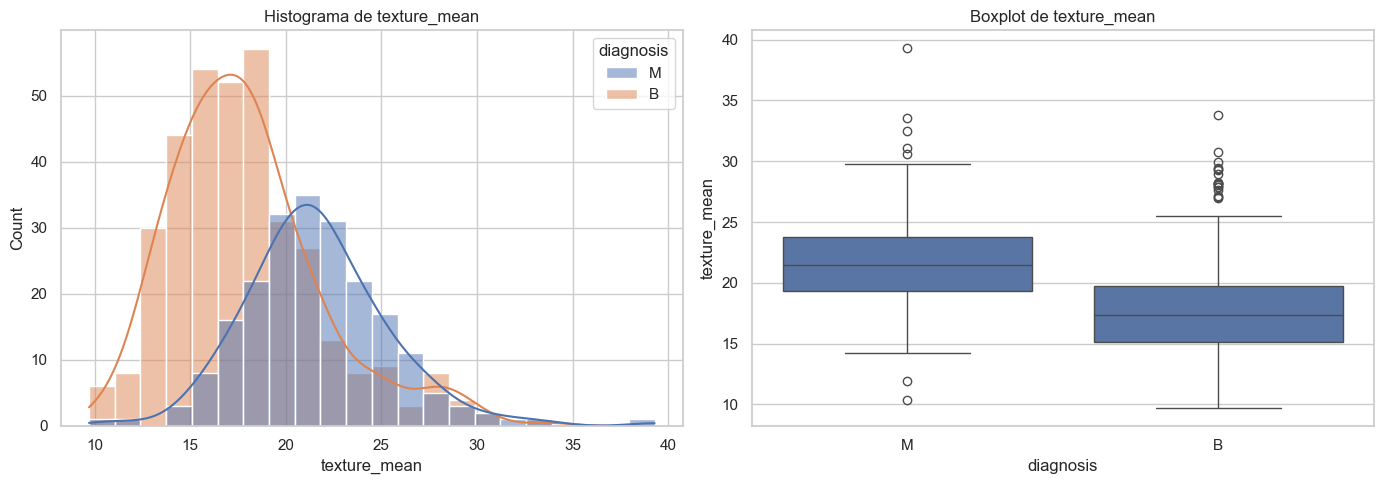

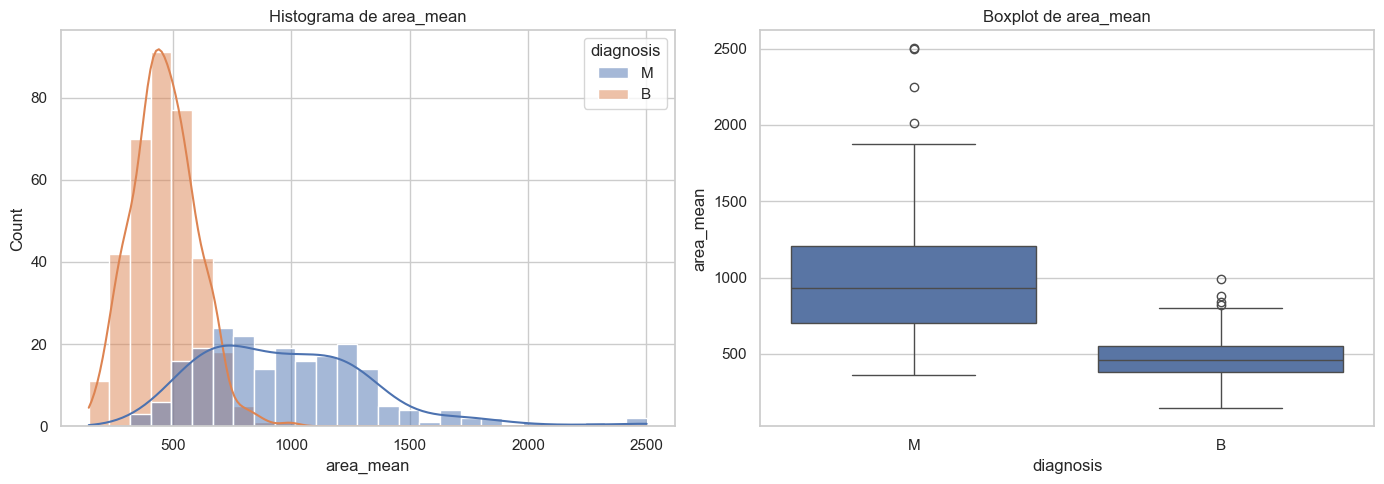

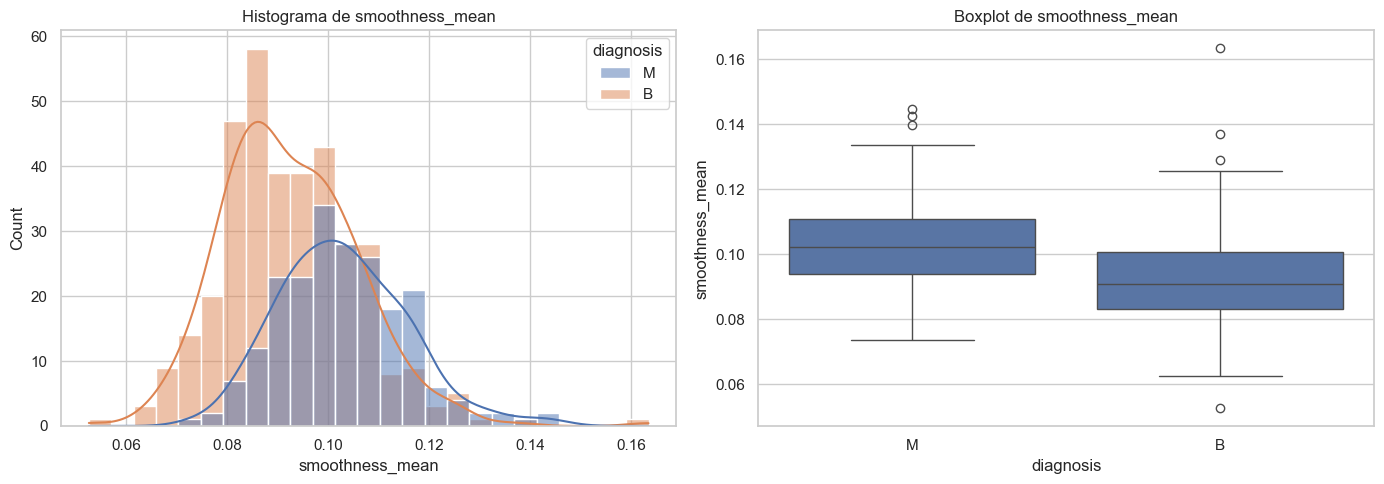

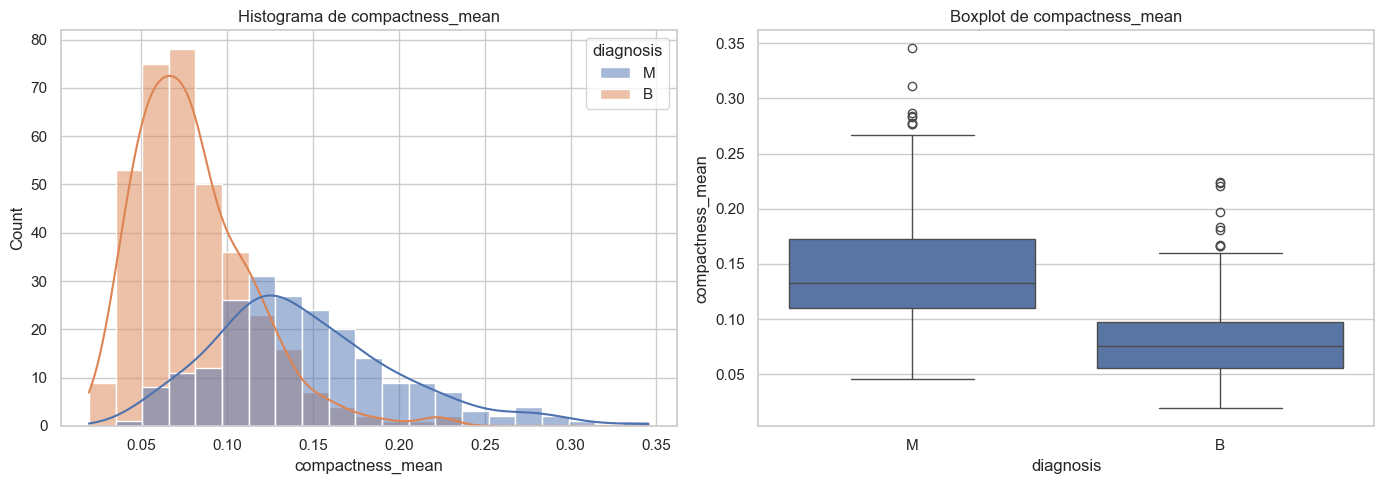

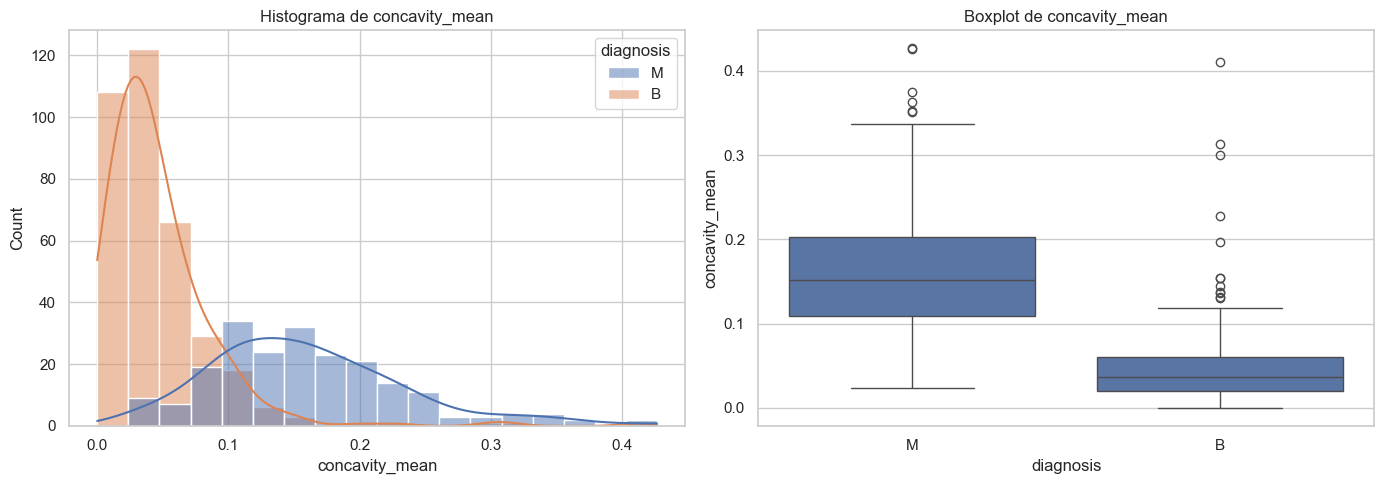

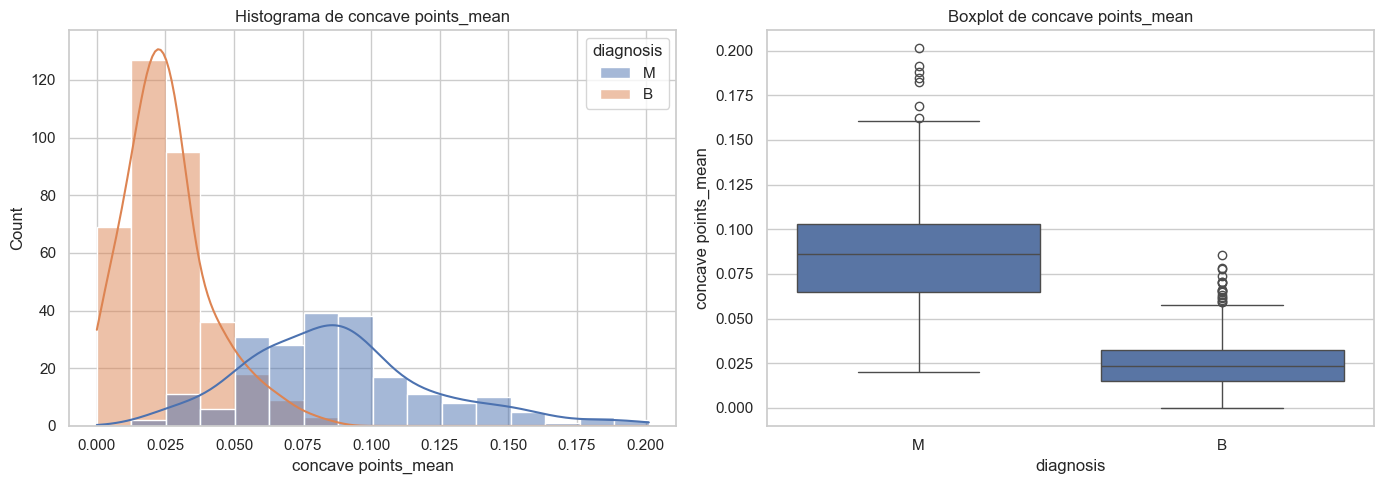

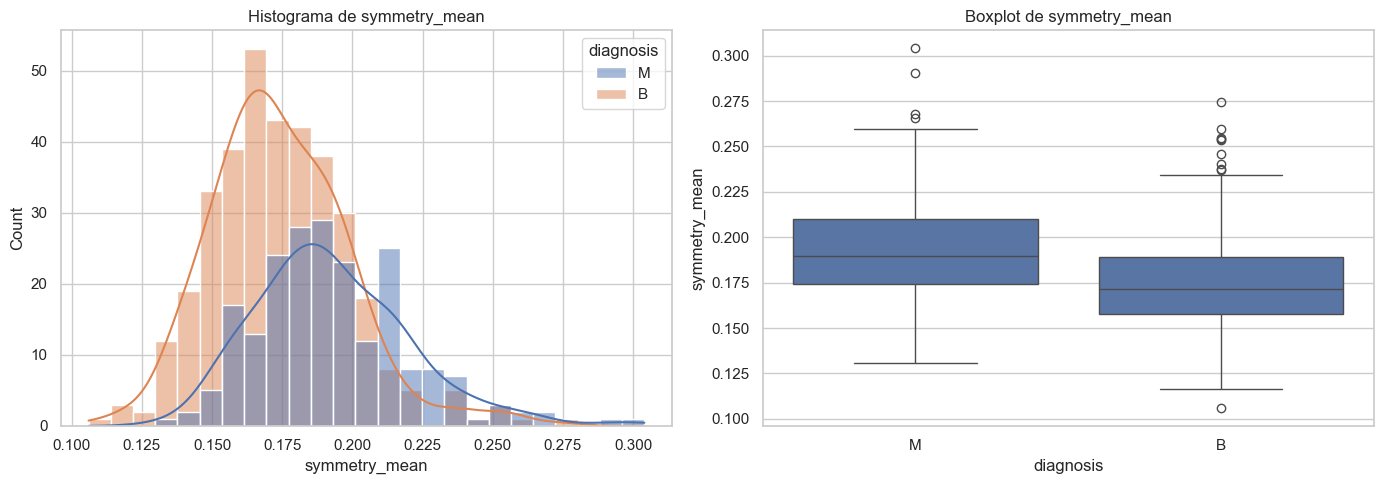

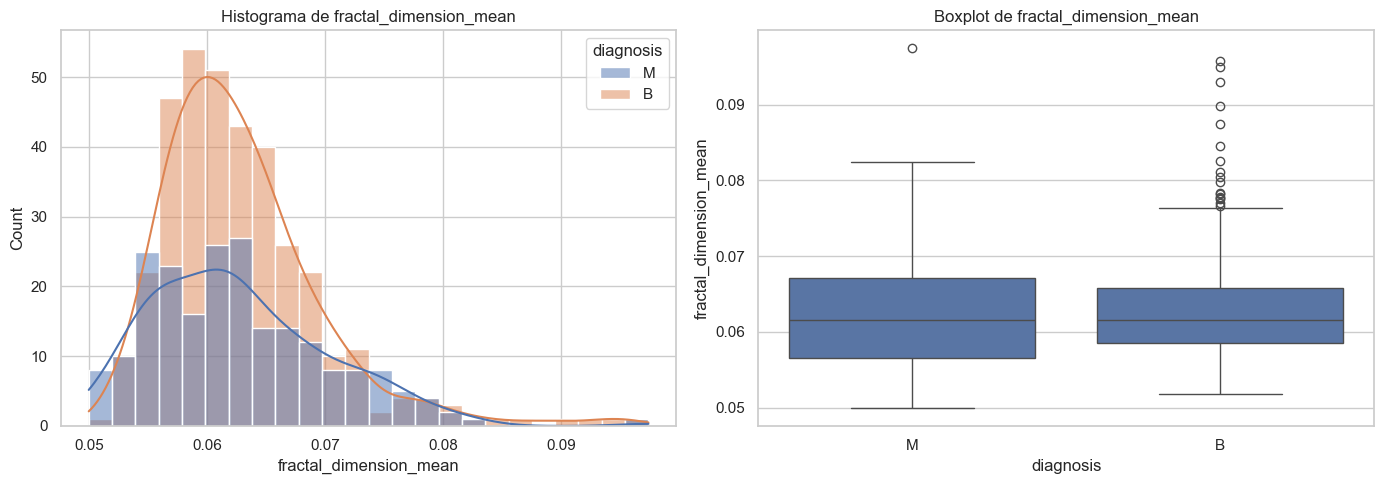

In [6]:
vars_mean = ['texture_mean', 'area_mean', 'smoothness_mean', 
             'compactness_mean', 'concavity_mean', 'concave points_mean', 
             'symmetry_mean', 'fractal_dimension_mean']

# Histogramas y Boxplots separados para el análisis individual de cada variable
for var in vars_mean:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    sns.histplot(data=df_prep, x=var, hue='diagnosis', kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {var}')
    
    # Boxplot
    sns.boxplot(data=df_prep, x='diagnosis', y=var, ax=axes[1])
    axes[1].set_title(f'Boxplot de {var}')
    
    plt.tight_layout()
    plt.show()

#### Scatterplots (Relaciones Bivariadas)

Se observan las relaciones bivariadas mediante scatterplots independientes para hacer el análisis de cada variable contra `area_mean` de forma individual.

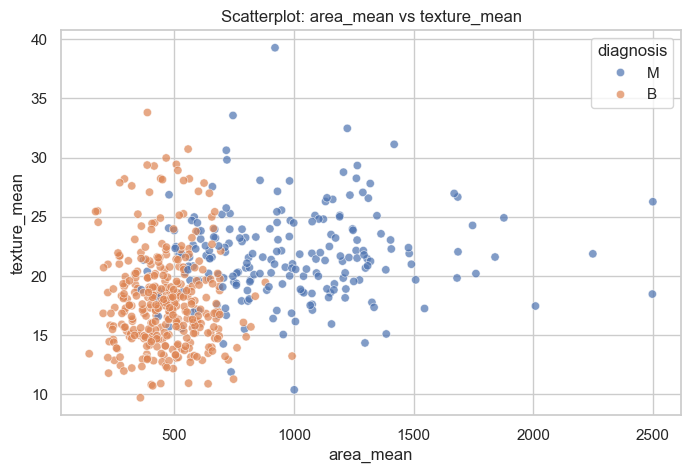

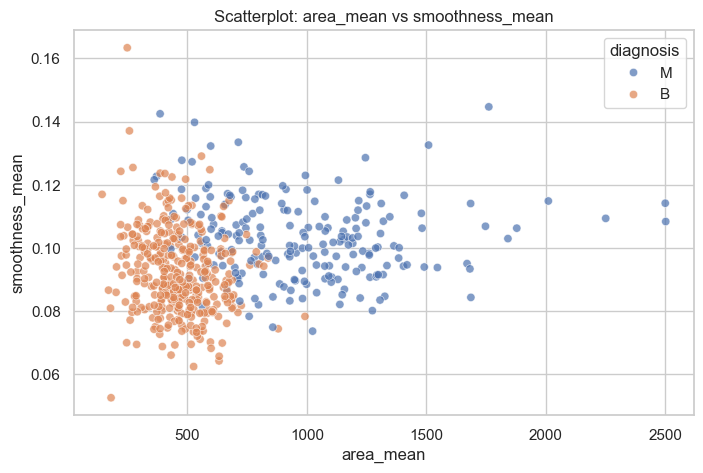

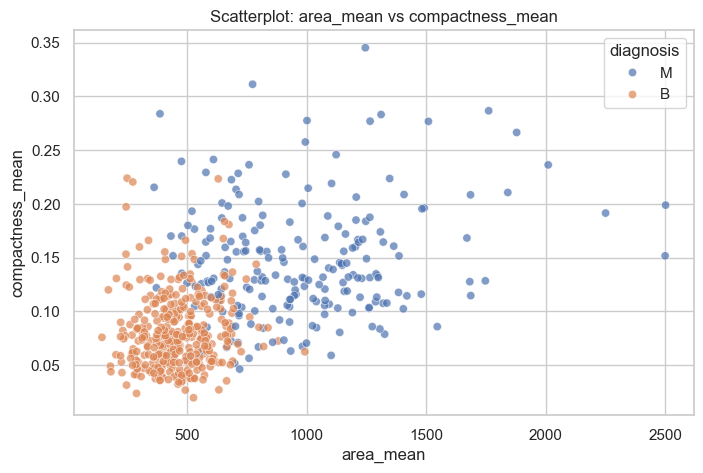

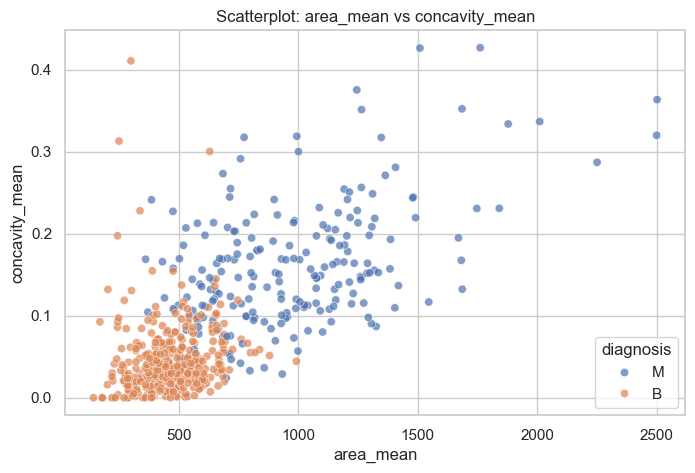

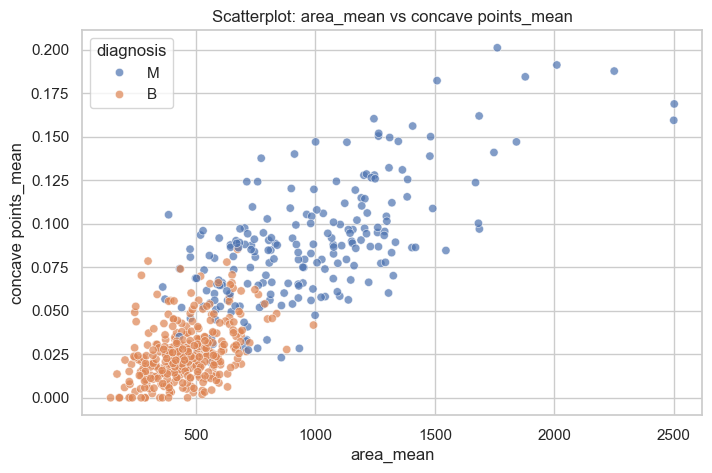

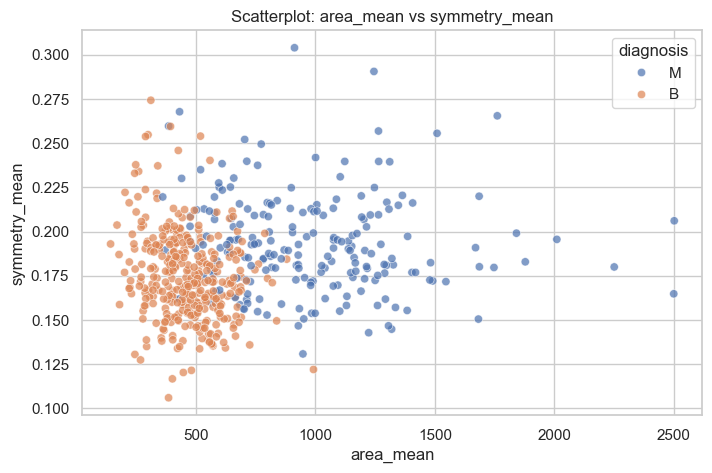

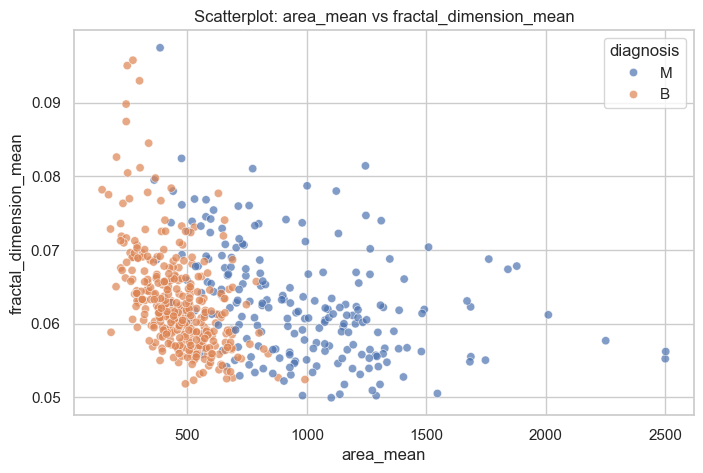

In [7]:
# Scatterplots separados
for var in vars_mean:
    if var != 'area_mean':
        plt.figure(figsize=(8, 5))
        sns.scatterplot(data=df_prep, x='area_mean', y=var, hue='diagnosis', alpha=0.7)
        plt.title(f'Scatterplot: area_mean vs {var}')
        plt.show()

#### Matriz de Correlación

Evaluación de la correlación cruzada exclusivamente para las variables `mean` consideradas en este estudio.

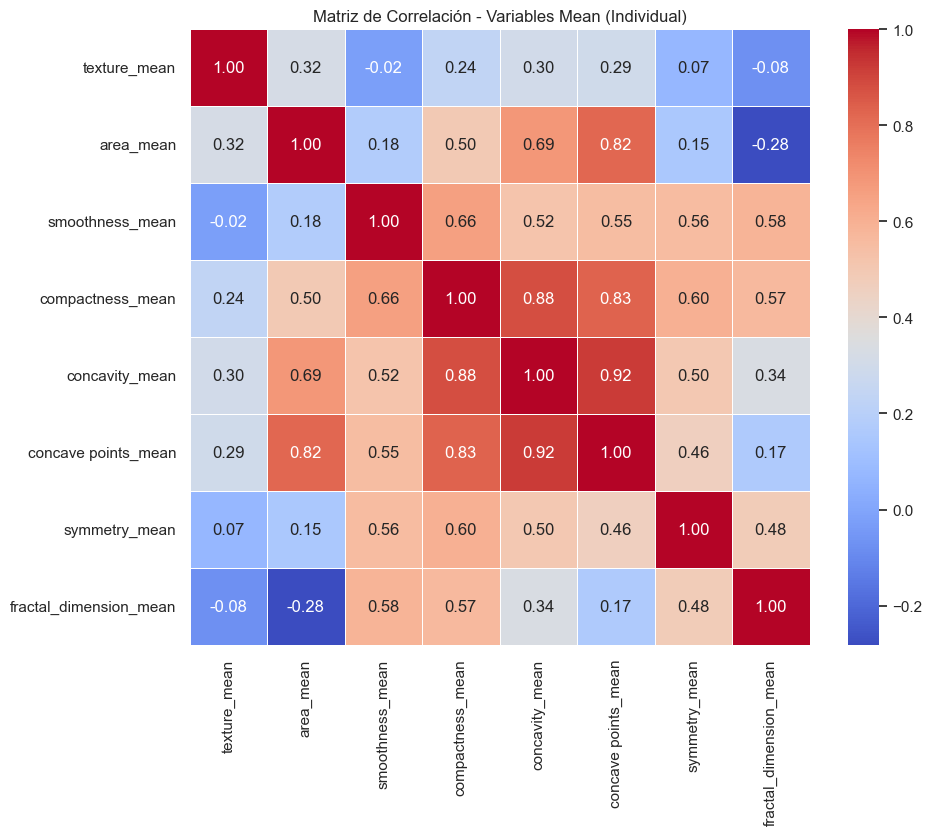

In [8]:
# Matriz de correlacion separada
plt.figure(figsize=(10, 8))
corr_matrix = df_prep[vars_mean].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Variables Mean (Individual)')
plt.show()

#### Gráficas Multivariadas

Se visualizan las relaciones conjuntas mediante un pairplot de las variables mean separadas del resto de los análisis para mantener la individualidad del estudio de este grupo.

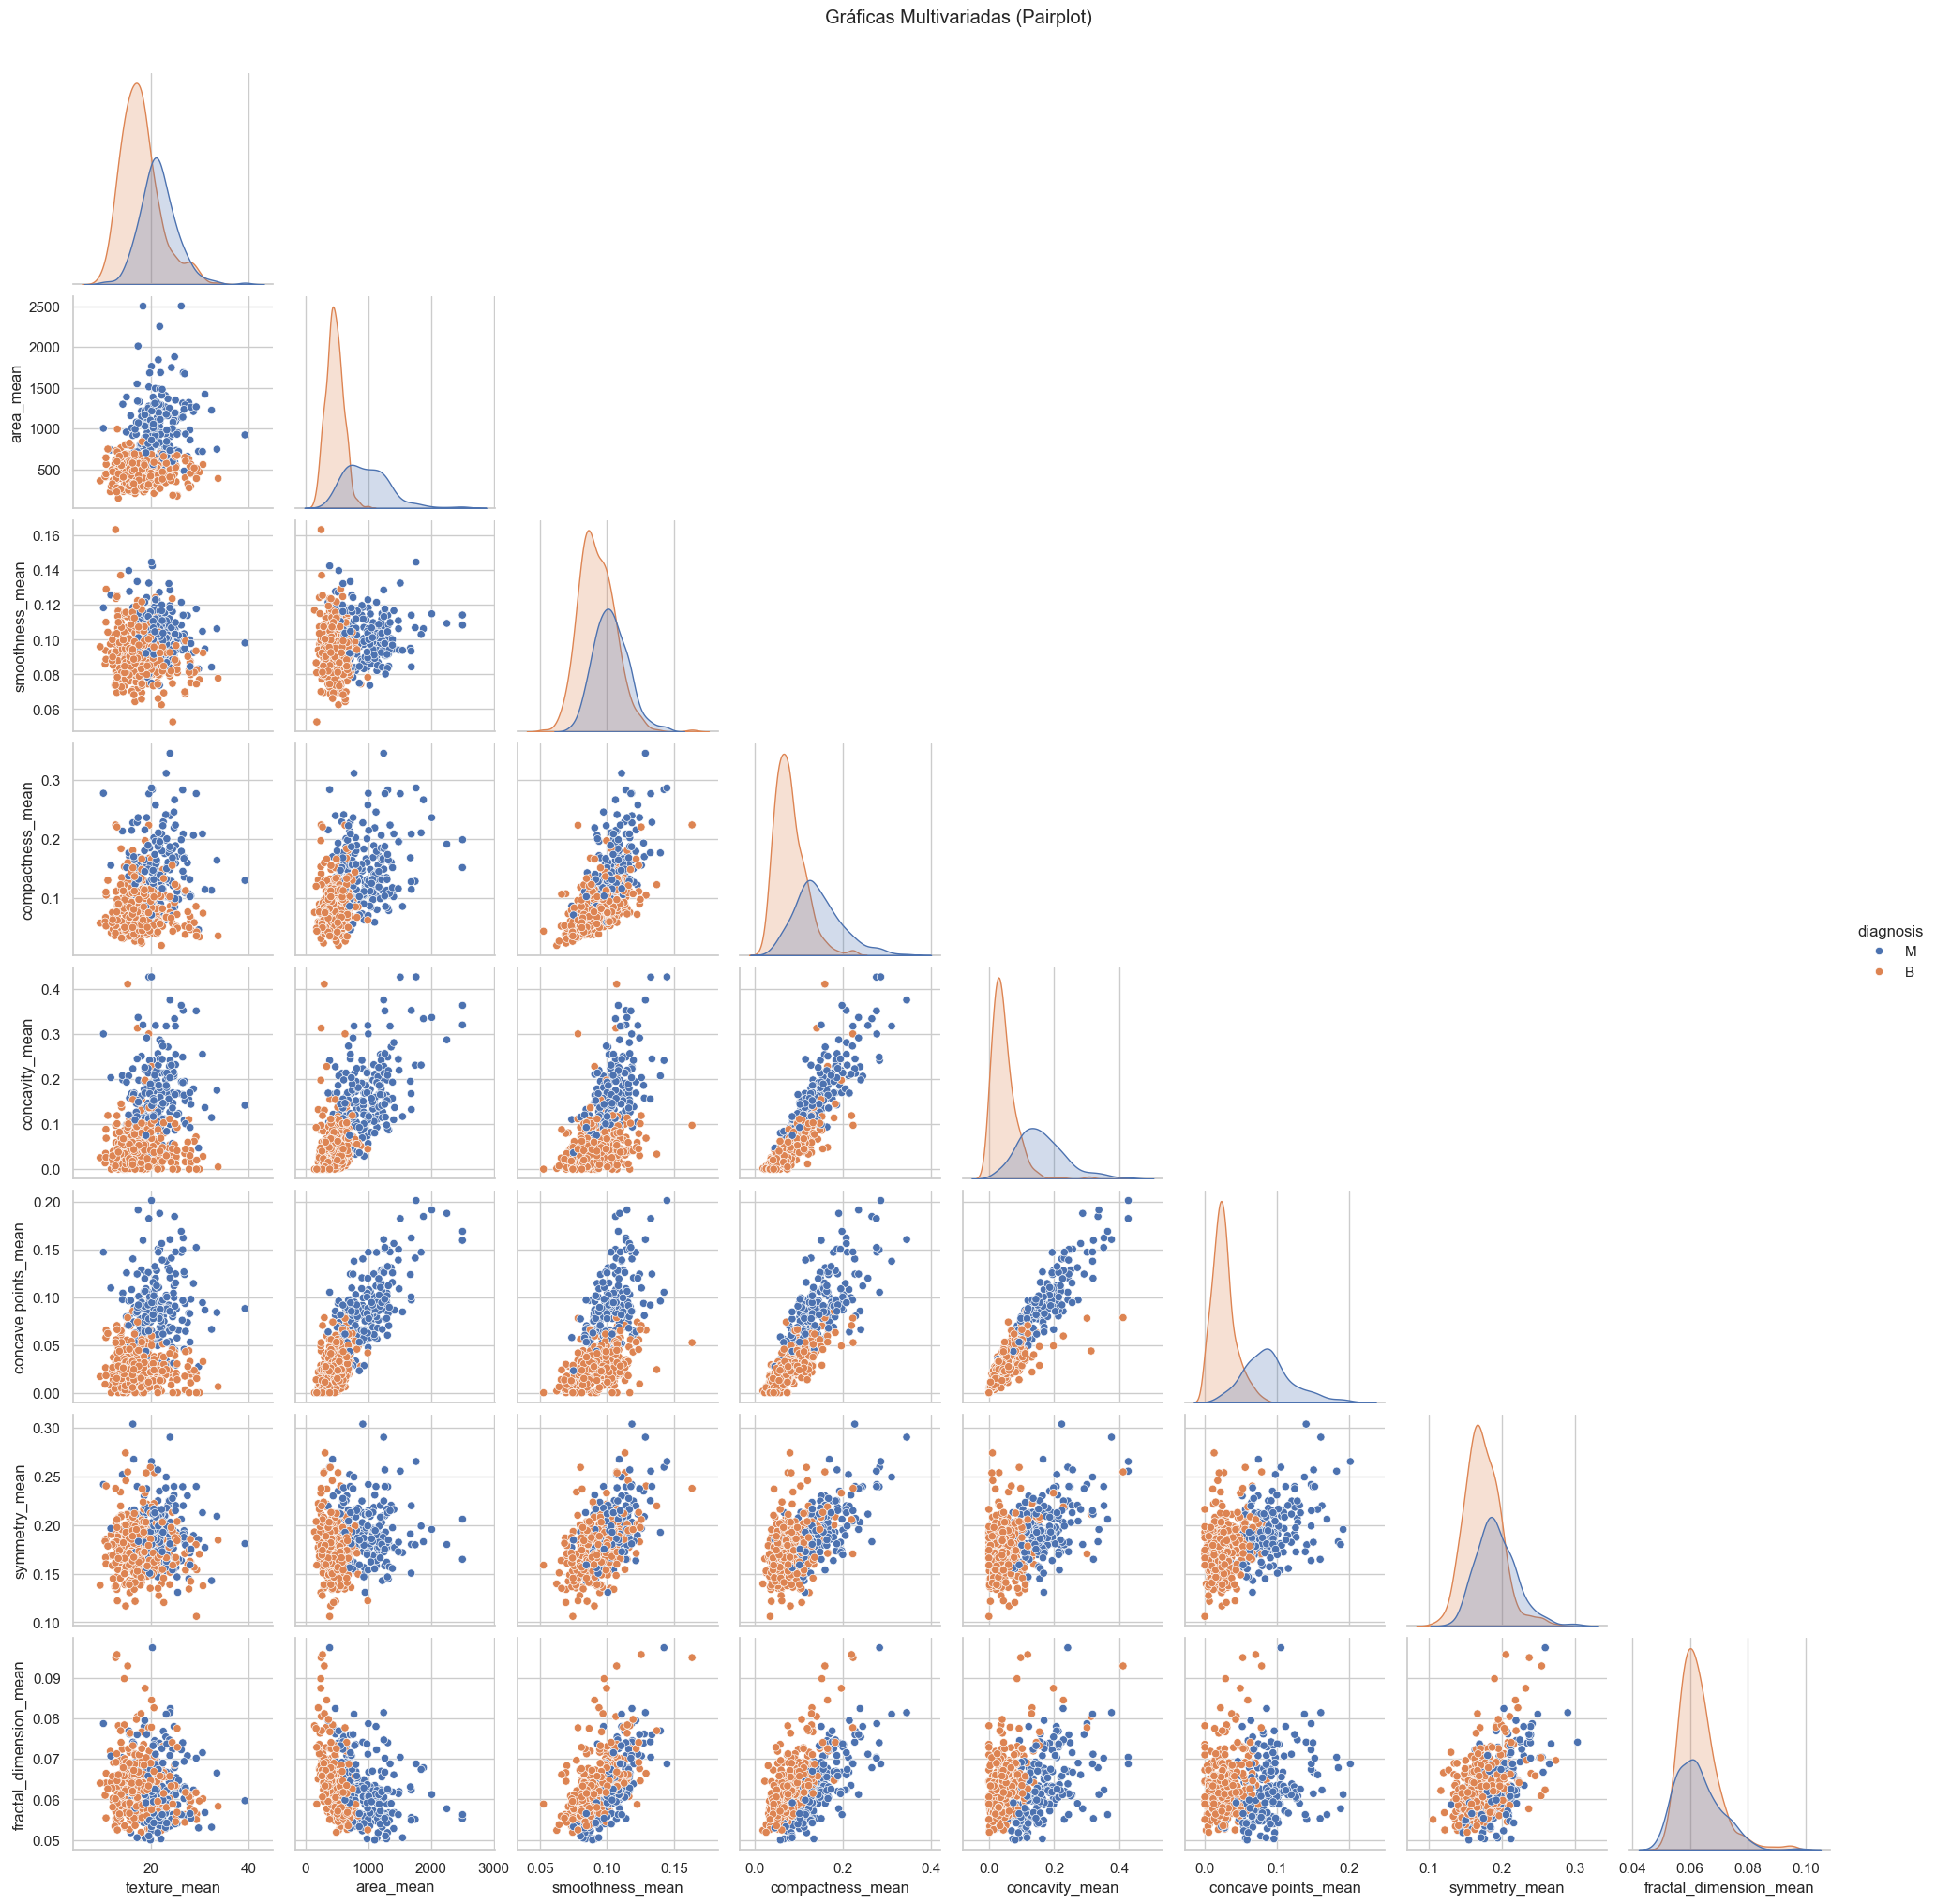

In [9]:
# Graficas Multivariadas
sns.pairplot(df_prep[vars_mean + ['diagnosis']], hue='diagnosis', corner=True)
plt.suptitle('Gráficas Multivariadas (Pairplot)', y=1.02)
plt.show()